In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Pytorch-Models/

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/1aJsbt04Jz9xcLP_lg7fvP4Bpdce6GQlC/Pytorch-Models


In [2]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/markerpensseg/train/")
count_images("datasets/markerpensseg/valid")

Total images: 225
Total images: 30


In [ ]:
# STEP 1: Install compatible PyTorch (2.0.1 + CUDA 11.7)
!pip install torch==2.0.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117

# STEP 2: Install OpenMMLab tools
!pip install -U openmim
!mim install "mmengine>=0.7.4"
!mim install "mmcv==2.1.0"

# STEP 3: Clone MMDetection & install
!git clone https://github.com/open-mmlab/mmdetection.git
%cd mmdetection
!pip install -e .

In [2]:
# STEP 4: Final check
!python -c "import torch; import mmcv; import mmdet; print('PyTorch:', torch.__version__); print('MMCV:', mmcv.__version__); print('MMDet:', mmdet.__version__)"

PyTorch: 2.0.1+cu117
MMCV: 2.1.0
MMDet: 3.3.0


In [ ]:
!git clone https://github.com/open-mmlab/mmdeploy.git
%cd mmdeploy
!pip install -e .

In [3]:
!python -c "import mmdeploy; print('MMDeploy:', mmdeploy.__version__)"

MMDeploy: 1.3.1


In [ ]:
!pip install numpy==1.24.4

In [4]:
!ls mmdetection/configs/queryinst/

metafile.yml
queryinst_r101_fpn_300-proposals_crop-ms-480-800-3x_coco.py
queryinst_r101_fpn_ms-480-800-3x_coco.py
queryinst_r50_fpn_1x_coco.py
queryinst_r50_fpn_300-proposals_crop-ms-480-800-3x_coco.py
queryinst_r50_fpn_ms-480-800-3x_coco.py
README.md


In [5]:
custom_cfg = """
_base_ = 'queryinst_r50_fpn_ms-480-800-3x_coco.py'

# Custom classes
dataset_type = 'CocoDataset'
metainfo = dict(classes=("CAP",))
num_classes = 1

vis_backends = [
    dict(type='LocalVisBackend'), # no Tensorboard backend
]
visualizer = dict(
    type='DetLocalVisualizer', vis_backends=vis_backends, name='visualizer')

# Paths
data_root = '/content/gdrive/MyDrive/Pytorch-Models/datasets/'
train_ann = data_root + 'markerpensseg/train/_annotations.coco.json'
val_ann = data_root + 'markerpensseg/valid/_annotations.coco.json'
train_img = data_root + 'markerpensseg/train/'
val_img = data_root + 'markerpensseg/valid/'

# Pipelines
train_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=True),
    dict(type='Resize', scale=(512, 512), keep_ratio=False),
    dict(type='RandomFlip', prob=0.5),
    dict(type='Pad', size=(512, 512), pad_val=dict(img=(114, 114, 114))),
    dict(type='PackDetInputs')
]

test_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='Resize', scale=(512, 512), keep_ratio=False),
    dict(type='Pad', size=(512, 512), pad_val=dict(img=(114, 114, 114))),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=True),
    dict(type='PackDetInputs', meta_keys=('img_id', 'img_path', 'ori_shape', 'img_shape', 'scale_factor'))
]

# Data loader
train_dataloader = dict(
    batch_size=8,
    num_workers=2,
    dataset=dict(
        _delete_=True,
        type=dataset_type,
        data_root=data_root,
        ann_file=train_ann,
        data_prefix=dict(img=train_img),
        filter_cfg=dict(filter_empty_gt=True, min_size=32),
        pipeline=train_pipeline,
        metainfo=dict(classes=("CAP",)),
    )
)

val_dataloader = dict(
    batch_size=8,
    num_workers=2,
    dataset=dict(
        _delete_=True,
        type=dataset_type,
        data_root=data_root,
        ann_file=val_ann,
        data_prefix=dict(img=val_img),
        pipeline=test_pipeline,
        test_mode=True,
        metainfo=dict(classes=("CAP",)),
    )
)

test_dataloader = val_dataloader

# Evaluator
val_evaluator = dict(type='CocoMetric', ann_file=val_ann, metric=['bbox', 'segm'])
# val_evaluator = dict(type='CocoMetric', ann_file=val_ann, metric=['bbox', 'segm'], classwise=True)
test_evaluator = val_evaluator

# Model
num_stages = 6
num_proposals = 100
model = dict(
    type='QueryInst',
    data_preprocessor=dict(
        type='DetDataPreprocessor',
        mean=[123.675, 116.28, 103.53],
        std=[58.395, 57.12, 57.375],
        bgr_to_rgb=True,
        pad_mask=True,
        pad_size_divisor=32),
    backbone=dict(
        type='ResNet',
        depth=50,
        num_stages=4,
        out_indices=(0, 1, 2, 3),
        frozen_stages=1,
        norm_cfg=dict(type='BN', requires_grad=True),
        norm_eval=True,
        style='pytorch',
        init_cfg=dict(type='Pretrained', checkpoint='torchvision://resnet50')),
    neck=dict(
        type='FPN',
        in_channels=[256, 512, 1024, 2048],
        out_channels=256,
        start_level=0,
        add_extra_convs='on_input',
        num_outs=4),
    rpn_head=dict(
        type='EmbeddingRPNHead',
        num_proposals=num_proposals,
        proposal_feature_channel=256),
    roi_head=dict(
        type='SparseRoIHead',
        num_stages=num_stages,
        stage_loss_weights=[1] * num_stages,
        proposal_feature_channel=256,
        bbox_roi_extractor=dict(
            type='SingleRoIExtractor',
            roi_layer=dict(type='RoIAlign', output_size=7, sampling_ratio=2),
            out_channels=256,
            featmap_strides=[4, 8, 16, 32]),
        mask_roi_extractor=dict(
            type='SingleRoIExtractor',
            roi_layer=dict(type='RoIAlign', output_size=14, sampling_ratio=2),
            out_channels=256,
            featmap_strides=[4, 8, 16, 32]),
        bbox_head=[
            dict(
                type='DIIHead',
                num_classes=num_classes,
                num_ffn_fcs=2,
                num_heads=8,
                num_cls_fcs=1,
                num_reg_fcs=3,
                feedforward_channels=2048,
                in_channels=256,
                dropout=0.0,
                ffn_act_cfg=dict(type='ReLU', inplace=True),
                dynamic_conv_cfg=dict(
                    type='DynamicConv',
                    in_channels=256,
                    feat_channels=64,
                    out_channels=256,
                    input_feat_shape=7,
                    act_cfg=dict(type='ReLU', inplace=True),
                    norm_cfg=dict(type='LN')),
                loss_bbox=dict(type='L1Loss', loss_weight=5.0),
                loss_iou=dict(type='GIoULoss', loss_weight=2.0),
                loss_cls=dict(
                    type='FocalLoss',
                    use_sigmoid=True,
                    gamma=2.0,
                    alpha=0.25,
                    loss_weight=2.0),
                bbox_coder=dict(
                    type='DeltaXYWHBBoxCoder',
                    clip_border=False,
                    target_means=[0., 0., 0., 0.],
                    target_stds=[0.5, 0.5, 1., 1.])) for _ in range(num_stages)
        ],
        mask_head=[
            dict(
                type='DynamicMaskHead',
                dynamic_conv_cfg=dict(
                    type='DynamicConv',
                    in_channels=256,
                    feat_channels=64,
                    out_channels=256,
                    input_feat_shape=14,
                    with_proj=False,
                    act_cfg=dict(type='ReLU', inplace=True),
                    norm_cfg=dict(type='LN')),
                num_convs=4,
                num_classes=num_classes,
                roi_feat_size=14,
                in_channels=256,
                conv_kernel_size=3,
                conv_out_channels=256,
                class_agnostic=False,
                norm_cfg=dict(type='BN'),
                upsample_cfg=dict(type='deconv', scale_factor=2),
                loss_mask=dict(
                    type='DiceLoss',
                    loss_weight=8.0,
                    use_sigmoid=True,
                    activate=False,
                    eps=1e-5)) for _ in range(num_stages)
        ]),
    # training and testing settings
    train_cfg=dict(
        rpn=None,
        rcnn=[
            dict(
                assigner=dict(
                    type='HungarianAssigner',
                    match_costs=[
                        dict(type='FocalLossCost', weight=2.0),
                        dict(type='BBoxL1Cost', weight=5.0, box_format='xyxy'),
                        dict(type='IoUCost', iou_mode='giou', weight=2.0)
                    ]),
                sampler=dict(type='PseudoSampler'),
                pos_weight=1,
                mask_size=28,
            ) for _ in range(num_stages)
        ]),
    test_cfg=dict(
        rpn=None, rcnn=dict(max_per_img=num_proposals, mask_thr_binary=0.5)))

# Schedule
max_epochs = 10
train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=10, val_interval=10)
val_cfg = dict(type='ValLoop')
test_cfg = dict(type='TestLoop')

# optimizer
optim_wrapper = dict(
    type='OptimWrapper',
    optimizer=dict(
        _delete_=True, type='AdamW', lr=0.0001, weight_decay=0.0001),
    paramwise_cfg=dict(
        custom_keys={'backbone': dict(lr_mult=0.1, decay_mult=1.0)}),
    clip_grad=dict(max_norm=0.1, norm_type=2))

# learning policy
param_scheduler = [
    dict(
        type='LinearLR', start_factor=0.001, by_epoch=False, begin=0, end=500),
    dict(
        type='MultiStepLR',
        begin=0,
        end=10,
        by_epoch=True,
        milestones=[7, 9],
        gamma=0.1
    )
]

# Logging and checkpointing
default_hooks = dict(
    logger=dict(type='LoggerHook', interval=2),
    checkpoint=dict(type='CheckpointHook', interval=2)
)

# Output path
work_dir = '/content/gdrive/MyDrive/Pytorch-Models/mmdetection/mmdet_outputs/queryinst_r50_markers'

# Load pretrained COCO model
load_from = 'https://download.openmmlab.com/mmdetection/v2.0/queryinst/queryinst_r50_fpn_mstrain_480-800_3x_coco/queryinst_r50_fpn_mstrain_480-800_3x_coco_20210901_103643-7837af86.pth'
"""

with open('mmdetection/configs/queryinst/queryinst_r50_markers.py', 'w') as f:
    f.write(custom_cfg)

In [6]:
!python mmdetection/tools/train.py mmdetection/configs/queryinst/queryinst_r50_markers.py --amp

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
04/08 17:22:22 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1109990086
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA 

In [12]:
%ls mmdetection/mmdet_outputs/queryinst_r50_markers/

20260408_172027/  epoch_10.pth  last_checkpoint  queryinst_r50_markers.py


In [11]:
!rm mmdetection/mmdet_outputs/queryinst_r50_markers/epoch_8.pth

In [13]:
!python mmdetection/tools/test.py mmdetection/configs/queryinst/queryinst_r50_markers.py mmdetection/mmdet_outputs/queryinst_r50_markers/epoch_10.pth

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
04/08 17:41:31 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1775961018
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA 

In [54]:
from mmdet.apis import init_detector, inference_detector
import mmcv

# Config and checkpoint paths
config_file = 'mmdetection/configs/queryinst/queryinst_r50_markers.py'
checkpoint_file = 'mmdetection/mmdet_outputs/queryinst_r50_markers/epoch_10.pth'

# Initialize the model
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or 'cpu'

# Image path
img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg'

# Run inference
result = inference_detector(model, img)
print(result)

Loads checkpoint by local backend from path: mmdetection/mmdet_outputs/queryinst_r50_markers/epoch_10.pth
<DetDataSample(

    META INFORMATION
    batch_input_shape: (512, 512)
    pad_shape: (512, 512)
    img_id: 0
    scale_factor: (0.3333333333333333, 0.25)
    img_path: '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg'
    ori_shape: (2048, 1536)
    img_shape: (512, 512)

    DATA FIELDS
    pred_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            bboxes: tensor([[ 982.6009,  955.6835, 1123.2019, 1155.7645],
                        [ 999.3140,  498.9700, 1309.4697, 1108.0297],
                        [ 796.7087, 1171.7618,  844.2953, 1248.1488],
                        [ 528.5792, 1182.5768,  803.3194, 1237.7164],
                        [ 980.6912,  956.3267, 1126.4608, 1152.6705],
                        [ 831.4510, 1168

Loads checkpoint by local backend from path: mmdetection/mmdet_outputs/queryinst_r50_markers/epoch_10.pth


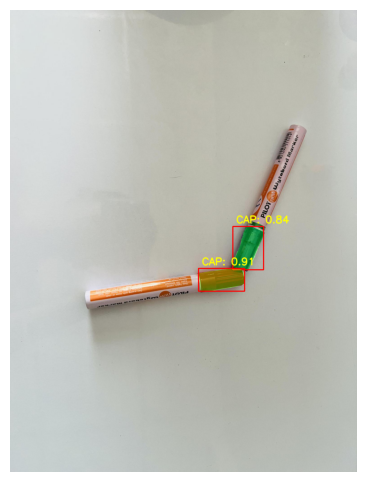

In [15]:
from mmdet.apis import init_detector, inference_detector
from mmdet.structures.mask import BitmapMasks
from mmdet.structures.bbox import HorizontalBoxes
import mmcv
import cv2
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import random

# Class labels
CLASS_LABELS = ["CAP"]

PRED_COLORS = {0: (0, 255, 0)}

# Config and checkpoint paths
config_file = 'mmdetection/configs/queryinst/queryinst_r50_markers.py'
checkpoint_file = 'mmdetection/mmdet_outputs/queryinst_r50_markers/epoch_10.pth'

# Initialize the model
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or 'cpu'

def draw_bbox_with_label(img, bbox, label, score, color=(0, 0, 255), thickness=3):
    xmin, ymin, xmax, ymax = map(int, bbox)
    # Draw rectangle
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, thickness)
    # Put label text
    cv2.putText(
        img, f"{label}: {score:.2f}", (xmin + 15, ymin - 15),
        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 3, cv2.LINE_AA
    )

# Image path
img_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg'
img = cv2.imread(img_path)
if img is None:
    raise Exception("Image not found or unreadable")

# Run inference
results = inference_detector(model, img_path)

# Access the prediction results from the DetDataSample object
pred_instances = results.pred_instances

# 1. Get original image dimensions
ori_h, ori_w = img.shape[:2]

# 2. Extract raw masks (these are currently 512x512 or padded size)
masks_tensor = pred_instances.masks
scores = pred_instances.scores
labels = pred_instances.labels

img_with_masks = img.copy()

for i in range(len(masks_tensor)):
    score = scores[i].item()
    if score < 0.5:
        continue

    # --- THE FIX: Resize the mask to the image size first ---
    # Convert [1, 512, 512] -> [H_original, W_original]
    mask_np = masks_tensor[i].cpu().numpy().astype(np.uint8)
    mask_resized = cv2.resize(mask_np, (ori_w, ori_h), interpolation=cv2.INTER_NEAREST)
    mask_bool = mask_resized > 0

    # --- Now get the box from the RESIZED mask ---
    # Find coordinates where mask is True
    pos = np.where(mask_bool)
    if pos[0].size > 0:
        ymin, xmin = np.min(pos[0]), np.min(pos[1])
        ymax, xmax = np.max(pos[0]), np.max(pos[1])
        bbox = [xmin, ymin, xmax, ymax]
    else:
        continue

    # 3. Draw using the resized mask and the new bbox
    label_id = labels[i].item()
    class_name = CLASS_LABELS[label_id]
    color = PRED_COLORS[label_id]

    colored_mask = np.zeros_like(img, dtype=np.uint8)
    colored_mask[mask_bool] = color
    img_with_masks = cv2.addWeighted(img_with_masks, 1.0, colored_mask, 0.4, 0)

    draw_bbox_with_label(img_with_masks, bbox, class_name, score, color=(0, 0, 255))

# Show result
img_with_bbox_rgb = cv2.cvtColor(img_with_masks, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(img_with_bbox_rgb)
plt.show()

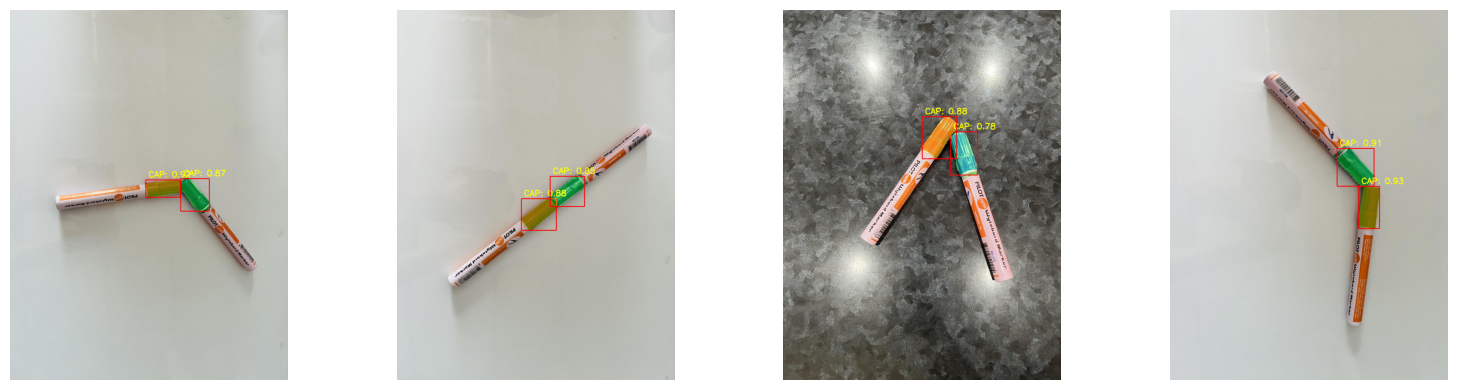

In [16]:
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/"

# visualization layout
N = 4
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 4 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(1, 4, ii+1)

    img = cv2.imread(image)

    results = inference_detector(model, image)

    # Access the prediction results from the DetDataSample object
    pred_instances = results.pred_instances

    ori_h, ori_w = img.shape[:2]

    # 2. Extract raw masks (these are currently 512x512 or padded size)
    masks_tensor = pred_instances.masks
    scores = pred_instances.scores
    labels = pred_instances.labels

    img_with_masks = img.copy()

    for i in range(len(masks_tensor)):
        score = scores[i].item()
        if score < 0.5:
            continue

        # --- THE FIX: Resize the mask to the image size first ---
        # Convert [1, 512, 512] -> [H_original, W_original]
        mask_np = masks_tensor[i].cpu().numpy().astype(np.uint8)
        mask_resized = cv2.resize(mask_np, (ori_w, ori_h), interpolation=cv2.INTER_NEAREST)
        mask_bool = mask_resized > 0

        # --- Now get the box from the RESIZED mask ---
        # Find coordinates where mask is True
        pos = np.where(mask_bool)
        if pos[0].size > 0:
            ymin, xmin = np.min(pos[0]), np.min(pos[1])
            ymax, xmax = np.max(pos[0]), np.max(pos[1])
            bbox = [xmin, ymin, xmax, ymax]
        else:
            continue

        # 3. Draw using the resized mask and the new bbox
        label_id = labels[i].item()
        class_name = CLASS_LABELS[label_id]
        color = PRED_COLORS[label_id]

        colored_mask = np.zeros_like(img, dtype=np.uint8)
        colored_mask[mask_bool] = color
        img_with_masks = cv2.addWeighted(img_with_masks, 1.0, colored_mask, 0.4, 0)

        draw_bbox_with_label(img_with_masks, bbox, class_name, score, color=(0, 0, 255))

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_masks, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()